In [1]:
import pandas as pd
import plotly.express as px
import jalali_pandas
import numpy as np

In [2]:
excel_file = pd.ExcelFile("data11.xlsx")
data = pd.read_excel('data11.xlsx')

### Tamirat Data Processing

In [10]:
tamirat_list_name = [name for name in excel_file.sheet_names if "الی" in name.lower()]

In [11]:
tamirat_data = pd.DataFrame()
for name in tamirat_list_name:
    df = pd.read_excel(excel_file, sheet_name=name)
    df['i'] = name
    tamirat_data = pd.concat([tamirat_data, df]).fillna('-')

In [12]:
tamirat_data.columns = tamirat_data.iloc[2].to_list()
tamirat_data.drop(index=[0, 1, 2], inplace=True)

In [13]:
tamirat_data.columns

Index(['Work code', 'order noumber', 'Repair date', 'Machine names',
       'Main system', 'Machine code', 'sub system', 'Repairman',
       'Type of work', 'تعمیرات2.6 الی 3.8', '-'],
      dtype='object')

In [14]:
px.bar(tamirat_data['Main system'].value_counts())

### Price and Open-Close Analysis

In [15]:
price_sheetname_list = [name for name in excel_file.sheet_names if "قیمت" in name]

In [16]:
price_data = pd.DataFrame()
for name in price_sheetname_list:
    df = pd.read_excel(excel_file, sheet_name=name)
    df['i'] = name
    price_data = pd.concat([price_data, df]).fillna('-')

In [17]:
price_data.columns = price_data.iloc[2].to_list()
price_data.drop(index=[0, 1, 2], inplace=True)

In [18]:
price_data.columns

Index(['order noumber', 'price', 'start', 'finish', 'قیمت دستور کار مهر'], dtype='object')

In [19]:
import jdatetime
import pandas as pd
import numpy as np
price_data['finish'] = np.where(price_data['finish'] == 0, price_data['start'], price_data['finish'])
def to_gregorian(jalali_str):
    try:
        if pd.isna(jalali_str) or jalali_str == 0:
            return pd.NaT
        y, m, d = map(int, str(jalali_str).split('/'))
        return jdatetime.date(y, m, d).togregorian()
    except (ValueError, AttributeError):
        return pd.NaT
price_data['start-g'] = pd.to_datetime(price_data['start'].apply(to_gregorian))
price_data['finish-g'] = pd.to_datetime(price_data['finish'].apply(to_gregorian))
price_data['duration'] = (price_data['finish-g'] - price_data['start-g']).dt.days
price_data["year"] = price_data['start-g'].dt.year
price_data["month"] = price_data['start-g'].dt.month
price_data['year_month_greg'] = price_data['start-g'].dt.strftime("%Y-%m")
def to_jalali_string(greg_date):
    if pd.isna(greg_date):
        return None
    j_date = jdatetime.date.fromgregorian(date=greg_date.date())
    return f"{j_date.year:04d}-{j_date.month:02d}"

price_data['year_month_jalali'] = price_data['start-g'].apply(to_jalali_string)

In [20]:
price_data.sort_values('duration', ascending=False).head(10)

,order noumber,price,start,finish,قیمت دستور کار مهر,start-g,finish-g,duration,year,month,year_month_greg,year_month_jalali
4119,1397852,4400000,1403/08/12,1404/09/20,آبان - قیمت,2024-11-02,2025-12-11,404.0,2024.0,11.0,2024-11,1403-08
6601,1393375,34400000,1403/12/04,1404/12/28,اسفند-قیمت,2025-02-22,2026-03-19,390.0,2025.0,2.0,2025-02,1403-12
3859,1395179,35000000,1403/08/21,1404/09/14,آبان - قیمت,2024-11-11,2025-12-05,389.0,2024.0,11.0,2024-11,1403-08
6461,1393895,10700000,1403/11/21,1404/11/28,بهمن-قیمت,2025-02-09,2026-02-17,373.0,2025.0,2.0,2025-02,1403-11
785,1452021,450000000,1404/05/29,1405/06/03,مرداد -قیمت,2025-08-20,2026-08-25,370.0,2025.0,8.0,2025-08,1404-05
5024,1398264,1600000,1403/12/07,1404/12/09,اسفند-قیمت,2025-02-25,2026-02-28,368.0,2025.0,2.0,2025-02,1403-12
5857,1323135,376000000,1403/11/30,1404/12/01,بهمن-قیمت,2025-02-18,2026-02-20,367.0,2025.0,2.0,2025-02,1403-11
9587,1461443,96000000,1403/09/12,1404/09/12,دی قیمت,2024-12-02,2025-12-03,366.0,2024.0,12.0,2024-12,1403-09
457,1462833,950000,1403/07/29,1404/07/29,مهر1403-قیمت,2024-10-20,2025-10-21,366.0,2024.0,10.0,2024-10,1403-07
9587,1461443,96000000,1403/09/12,1404/09/12,آذر-قیمت,2024-12-02,2025-12-03,366.0,2024.0,12.0,2024-12,1403-09


### price and tamirat lookup

In [21]:
merged_tamirat_price = tamirat_data.merge(price_data, left_on='order noumber', right_on='order noumber', how='inner')
merged_tamirat_price['quarter'] = merged_tamirat_price["Repair date"].jalali.parse_jalali("%Y/%m/%d").jalali.quarter

In [23]:
# Aggregating with rounding for cleaner presentation
report = (
    merged_tamirat_price
    .groupby(['quarter'])
    .agg({
        'duration': 'mean', 
        'price': 'mean', 
        'Work code': 'count'
    })
    .reset_index()
    .sort_values('duration', ascending=False)
    .round(2) # Keeps decimals in check
)

print(report)

TypeError: agg function failed [how->mean,dtype->object]

### Machines Properties

In [24]:
machine_bank = pd.read_excel('data.xlsx', sheet_name='بانک ماشین آلات')

In [25]:
merged_tamirat_price_bank = merged_tamirat_price.merge(machine_bank, on='Machine code')

In [26]:
px.bar(merged_tamirat_price_bank['UnitGroup'].value_counts())

### road property

In [27]:
road_bank = pd.read_excel('data.xlsx', sheet_name='road')

In [28]:
import pandas as pd
import numpy as np

# --- PREVIOUS CLEANUP CODE (From your snippet) ---
if 'level_0' in merged_tamirat_price_bank.columns:
    merged_tamirat_price_bank = merged_tamirat_price_bank.drop(columns=['level_0'])
if 'level_0' in road_bank.columns:
    road_bank = road_bank.drop(columns=['level_0'])

if 'UnitGroup' not in merged_tamirat_price_bank.columns:
    merged_tamirat_price_bank = merged_tamirat_price_bank.reset_index()
if 'UnitGroup' not in road_bank.columns:
    road_bank = road_bank.reset_index()

# ==============================================================================
# NEW SOLUTION START
# ==============================================================================

# 1. Get the list of valid Province names (Keys) from road_bank
#    Example: ['استان کرمان', 'استان تهران', 'استان فارس', ...]
valid_provinces = road_bank['UnitGroup'].unique()

# 2. Define a function to find the correct merge key
def find_correct_province(row):
    current_group = row['UnitGroup']
    
    # CASE A: The UnitGroup is already a valid province (e.g., "استان کرمان")
    if current_group in valid_provinces:
        return current_group
    
    # CASE B: The UnitGroup is a category (e.g., "1 راه و شهرسازی")
    # We must look into 'UnitName' to find the province
    unit_name = str(row['UnitName']) if pd.notnull(row['UnitName']) else ""
    
    # Check if any valid province name is hidden inside UnitName
    for prov in valid_provinces:
        # We need to handle the "استان" prefix. 
        # If road_bank has "استان کرمان", we want to search for just "کرمان" inside UnitName
        clean_search_term = prov.replace('استان', '').strip()
        
        if clean_search_term in unit_name:
            return prov  # Return the standard key matching road_bank (e.g., "استان کرمان")
            
    # Fallback: If no province is found, keep original (or return None)
    return current_group

# 3. Apply the function to create a temporary merge key
merged_tamirat_price_bank['Temp_Merge_Key'] = merged_tamirat_price_bank.apply(find_correct_province, axis=1)

# 4. Perform the merge using the NEW key for the left side, and 'UnitGroup' for the right side
merged_tamirat_price_bank_road = merged_tamirat_price_bank.merge(
    road_bank, 
    left_on='Temp_Merge_Key',  # Use the normalized column we just made
    right_on='UnitGroup',      # Use the standard column in road_bank
    how='left',                # 'left' keeps your original data, 'outer' keeps everything
    suffixes=('', '_road')     # Handles duplicate column names
)

# 5. Cleanup: Drop the temporary key and the extra UnitGroup column from the right table if needed
# Note: Because we used different join keys (left_on/right_on), pandas keeps both keys.
# You might want to drop 'UnitGroup_road' or 'Temp_Merge_Key' depending on your preference.
if 'Temp_Merge_Key' in merged_tamirat_price_bank_road.columns:
    merged_tamirat_price_bank_road = merged_tamirat_price_bank_road.drop(columns=['Temp_Merge_Key'])

print("Merge successful with Province extraction!")
print(merged_tamirat_price_bank_road[['UnitGroup', 'UnitName']].head())

Merge successful with Province extraction!
              UnitGroup                                UnitName
0  استان سمنان (شاهرود)   اداره ماشین آلات استان سمنان (شاهرود)
1  استان سمنان (شاهرود)   اداره ماشین آلات استان سمنان (شاهرود)
2  استان سمنان (شاهرود)   اداره ماشین آلات استان سمنان (شاهرود)
3  استان سمنان (شاهرود)   اداره ماشین آلات استان سمنان (شاهرود)
4  استان سمنان (شاهرود)   اداره ماشین آلات استان سمنان (شاهرود)


### performance Machine

In [29]:
perform_file = pd.ExcelFile("FINAL_ALL_FILES_COMBINED.xlsx")
perform = pd.read_excel('FINAL_ALL_FILES_COMBINED.xlsx')

In [143]:
Merged_Full_Data = merged_tamirat_price_bank_road.merge(perform, on=['year_month_jalali', 'Machine code'], 
    how='inner', # Use 'left' if you want to keep machines even if they had no repairs
    suffixes=('_perf', '_repair')
)

In [144]:

Merged_Full_Data = Merged_Full_Data.sort_values(by=['Machine code', 'year_month_jalali'])

Merged_Full_Data['Mileage between failuers'] = ( Merged_Full_Data.groupby('Machine code')['Mileage (KM)'].shift(-1) - Merged_Full_Data['Mileage (KM)'])
Merged_Full_Data['On time (minutes) between failuers'] = (Merged_Full_Data.groupby('Machine code')['On time (minutes)'].shift(-1) - Merged_Full_Data['On time (minutes)'])
Merged_Full_Data['Mileage between failuers'] = Merged_Full_Data['Mileage between failuers'].fillna(0)
Merged_Full_Data['On time (minutes) between failuers'] = Merged_Full_Data['On time (minutes) between failuers'].fillna(0)

# 4. Critical Step: Clip negative values
# If a counter reset to 0, the math (0 - 500,000) creates a massive negative.
# Clipping to 0 ensures your averages aren't skewed by bad data.
Merged_Full_Data['Mileage between failuers'] = Merged_Full_Data['Mileage between failuers'].clip(lower=0)
Merged_Full_Data['On time (minutes) between failuers'] = Merged_Full_Data['On time (minutes) between failuers'].clip(lower=0)

In [100]:
x = Merged_Full_Data["Mileage between failuers"]
(x==0).sum()

np.int64(306270)

In [101]:
Merged_Full_Data["Mileage between failuers_transform"] = Merged_Full_Data.groupby(["Machine code", "year_month_jalali"])["Mileage between failuers"].transform("max")
(Merged_Full_Data["Mileage between failuers_transform"]==0).sum()

np.int64(114464)

In [102]:
Merged_Full_Data['On time (minutes) between failuers_transform'] =Merged_Full_Data.groupby(["Machine code", "year_month_jalali"])["On time (minutes) between failuers"].transform("max")
(Merged_Full_Data['On time (minutes) between failuers_transform']==0).sum()

np.int64(115038)

In [103]:
total_rows = len(Merged_Full_Data)
print(f"Total rows in dataset: {total_rows}")

Total rows in dataset: 378134


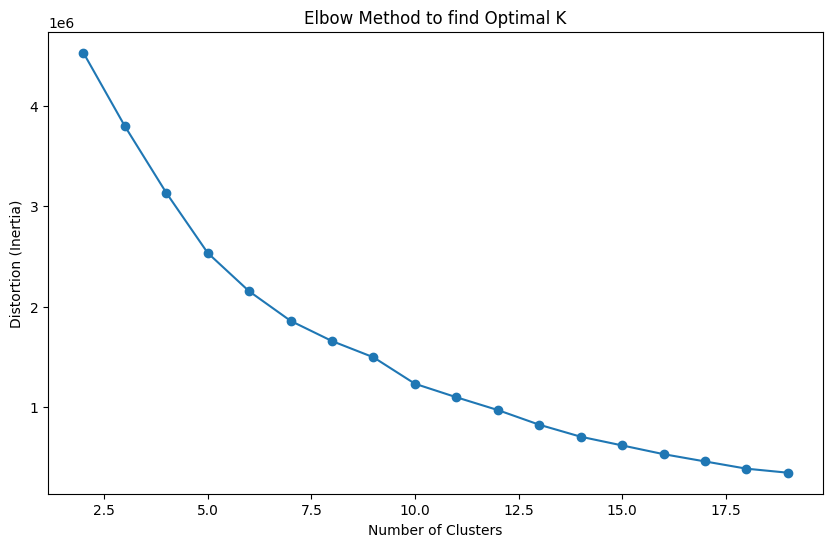

In [145]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
road_features1_columns = [
    'Total Absolute Road Length (km)', '% of Main Roads (Arterial Roads)', '% of Freeways (Motorways)', 
    '% of Highways (Expressways)', '% of Minor Roads (Secondary Roads)', '% of Rural Roads', 
    '% of Transit Roads', '% of Tunnel Length', '% of Bridge Length', 'Road Length by Region',  'Weather Type', 
]
road_data = Merged_Full_Data[road_features1_columns].copy()
road_data = pd.get_dummies(road_data, columns=['Weather Type'])
road_data = road_data.fillna(0)

scaler = StandardScaler()
road_data_scaled = scaler.fit_transform(road_data)
distorsions = []
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=22)
    kmeans.fit(road_data_scaled)
    distorsions.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 20), distorsions, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion (Inertia)')
plt.title('Elbow Method to find Optimal K')
plt.show()
n_clusters = 9 
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=22)
Merged_Full_Data['Road_Profile1_Cluster'] = kmeans.fit_predict(road_data_scaled)


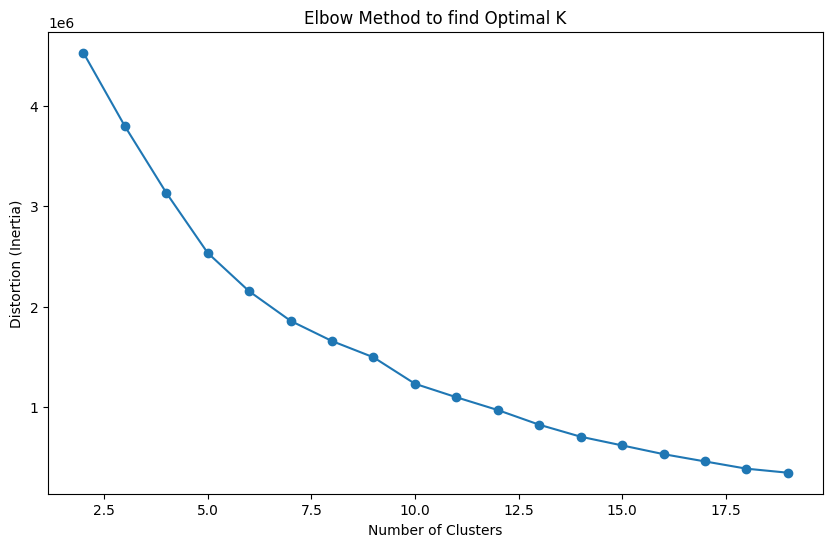

In [146]:

road_features_columns = [
    '% of Road in Plains (Flat Terrain)', '% of Length in Mountainous Terrain', 
    'Length of Road in Rolling Terrain (Hilly)%'
]
road_data1 = Merged_Full_Data[road_features_columns].copy()
road_data1 = road_data.fillna(0)

scaler = StandardScaler()
road_data1_scaled = scaler.fit_transform(road_data1)
distorsions = []
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=22)
    kmeans.fit(road_data1_scaled)
    distorsions.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 20), distorsions, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion (Inertia)')
plt.title('Elbow Method to find Optimal K')
plt.show()
n_clusters = 8 
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=22)
Merged_Full_Data['Topographic_Features_Cluster'] = kmeans.fit_predict(road_data_scaled)


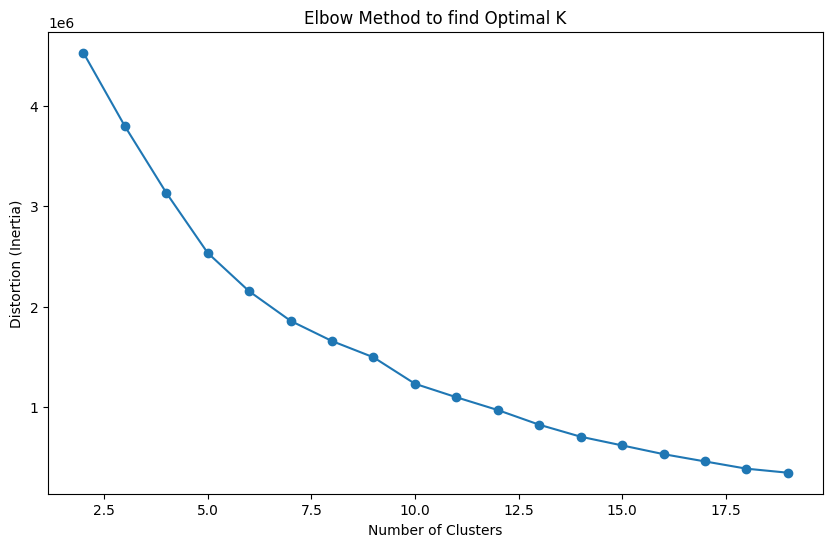

In [147]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
road_features3_columns = [
    'Road Length at Altitude < 500', '% of Road Length at Altitude 500 to 1000',
    '% of Road Length at Altitude 1000 to 1500', '% of Road Length at Altitude 1500 to 2000',
    '% of Road Length at Altitude 2000 to 2500', '% of Road Length at Altitude 2500 to [3000]',
    '% of Road Length at Altitude > [3000]', 'Total Route Length based on Elevation Level',
    'Saturation Flow Adjustment Factors'
]
road4_data = Merged_Full_Data[road_features3_columns].copy()
road4_data = road_data.fillna(0)

scaler = StandardScaler()
road_data4_scaled = scaler.fit_transform(road4_data)
distorsions = []
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=22)
    kmeans.fit(road_data4_scaled)
    distorsions.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 20), distorsions, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion (Inertia)')
plt.title('Elbow Method to find Optimal K')
plt.show()
n_clusters = 8 
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=22)
Merged_Full_Data['Height_level_Cluster'] = kmeans.fit_predict(road_data_scaled)


In [150]:
Merged_Full_Data.to_pickle("finall_mwrged_full_data.pickle")

In [48]:
Merged_Full_Data = pd.read_pickle('finall_mwrged_full_data.pickle')

In [49]:
total_rows = len(Merged_Full_Data)
print(f"Total rows in dataset: {total_rows}")

Total rows in dataset: 378134


In [59]:
len(Merged_Full_Data.columns)


99

In [51]:
Merged_Full_Data['MBF'] =Merged_Full_Data.groupby(["Machine code", "year_month_jalali"])["Mileage between failuers"].transform("max")

In [52]:
total_rows = len(Merged_Full_Data)
print(f"Total rows in dataset: {total_rows}")

Total rows in dataset: 378134


In [53]:
initial_features = [
    # 'Repair date', 
    'Machine names_x',
    'Type of work',
    # 'year_month_jalali',
    'quarter',
    'CompanyName',
    'Category',
    'Weather Type',
    'Section',
    'BuildDate',
    'CarType',
    #'Road_Profile_Cluster',
    'Average speed',
    'Maximum speed',
    'Travel time',
    'Repairman',
    'Main system',
    # 'UnitName',
    'CarGroup_perf',
    'Road_Profile1_Cluster',
       'Topographic_Features_Cluster', 'Height_level_Cluster'
]

location_features = [
    'Total Absolute Road Length (km)',
    '% of Main Roads (Arterial Roads)',
    '% of Freeways (Motorways)',
    '% of Highways (Expressways)',
    '% of Minor Roads (Secondary Roads)',
            '% of Rural Roads',
        '% of Transit Roads',
        '% of Tunnel Length',
        '% of Bridge Length',
        'Road Length by Region',
    '% of Road in Plains (Flat Terrain)',
    '% of Length in Mountainous Terrain',
    'Length of Road in Rolling Terrain (Hilly)%',
                'Weather Type',
    'Road Length at Altitude < 500',
    '% of Road Length at Altitude 500 to 1000',
    '% of Road Length at Altitude 1000 to 1500',
    '% of Road Length at Altitude 1500 to 2000',
    '% of Road Length at Altitude 2000 to 2500',
    '% of Road Length at Altitude 2500 to [3000]',
    '% of Road Length at Altitude > [3000]',
    'Total Route Length based on Elevation Level',
    'Saturation Flow Adjustment Factors',
            'UnitGroup_road',

]

features = initial_features

Targets = [
    'price',
    'duration'
    'Main system',
    'Mileage between failuers'
]

In [46]:
# 1. Convert price to numeric, turning text/errors into NaN (Not a Number)
#Merged_Full_Data['price'] = pd.to_numeric(Merged_Full_Data['price'], errors='coerce')

# 2. Drop rows where price is now NaN (qcut cannot handle missing values)
#Merged_Full_Data = Merged_Full_Data.dropna(subset=['price'])

# 3. Filter out zero or negative prices if they exist (common in repair data)
Merged_Full_Data = Merged_Full_Data[Merged_Full_Data['price'] > 0]

# 4. Now run the qcut
Merged_Full_Data['price_category'] = pd.qcut(
    Merged_Full_Data['price'], 
    q=5, 
    labels=[0, 1, 2, 3, 4]
)

print("Success! Price categories created.")
print(Merged_Full_Data['price_category'].value_counts())

Success! Price categories created.
price_category
0    21165
4    21137
3    21136
2    21133
1    21111
Name: count, dtype: int64


In [54]:
total_rows = len(Merged_Full_Data)
print(f"Total rows in dataset: {total_rows}")

Total rows in dataset: 378134


In [55]:
from sklearn.preprocessing import OrdinalEncoder
categorlal_features = ['Machine names_x', 
                       'Type of work', 
                       'CompanyName', 'Category', 
                       'Weather Type', 'Section', 
                       'CarType', 'Main system', 
                       'UnitName', 'CarGroup_perf', 'Repairman']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 3. Transform the data
Merged_Full_Data[categorlal_features] = encoder.fit_transform(Merged_Full_Data[categorlal_features].astype(str))

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
Merged_Full_Data['price_category'] = pd.qcut(
    Merged_Full_Data['price'], 
    q=5, 
    labels=[0, 1, 2, 3, 4]
)
# --- PRE-CHECK: Ensure numeric types for your features ---
# Machine learning models cannot handle 'Object' or 'String' types in X.
for col in features:
    Merged_Full_Data[col] = pd.to_numeric(Merged_Full_Data[col], errors='coerce')

# Drop any rows that became NaN after conversion to keep the model clean
Merged_Full_Data = Merged_Full_Data.dropna(subset=features + ['price_category'])

# 1. Define Features (X) and Target (y)
X = Merged_Full_Data[features]
y = Merged_Full_Data['price_category']

# 2. Split data (80% Train, 20% Test)
# 'stratify=y' ensures the balance of price categories is the same in both sets.
# 2. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and Train the Model
model = model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12,         # Stops trees from becoming infinitely deep
    min_samples_leaf=10,  # Prevents the model from creating rules for single data points
    max_samples=0.8,      # Each tree only sees 80% of the data (increases diversity)
    n_jobs=-1,            # Uses all your CPU cores
    random_state=42
)
model.fit(X_train, y_train)
# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Validation Scores
print("--- Validation Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

TypeError: '<' not supported between instances of 'int' and 'str'

In [41]:
from sklearn.metrics import accuracy_score

# Predict on training data
y_train_pred = model.predict(X_train)

# Calculate scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}")
print(f"Gap: {train_acc - test_acc:.2%}")

Training Accuracy: 66.50%
Testing Accuracy: 62.22%
Gap: 4.28%


In [ ]:
def learning_curve(model):
    import matplotlib.pyplot as plt
    from sklearn.metrics import accuracy_score

    # 1. Reduce the dataset size for the plot if needed (e.g., use 20k samples total)
    # 2. Define specific training sizes to test
    subset_sizes = np.linspace(500, len(X_train), 5).astype(int)
    train_accs = []
    test_accs = []

    for size in subset_sizes:
        # Train on a small slice of the training data
        model.fit(X_train[:size], y_train[:size])
        
        # Record accuracy
        train_accs.append(accuracy_score(y_train[:size], model.predict(X_train[:size])))
        test_accs.append(accuracy_score(y_test, model.predict(X_test)))

    # Plotting the results
    plt.figure(figsize=(10, 5))
    plt.plot(subset_sizes, train_accs, 'o-', color="r", label="Training score")
    plt.plot(subset_sizes, test_accs, 'o-', color="g", label="Test score")
    plt.title("Fast Learning Curve (Accuracy vs Training Size)")
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()
    return plt

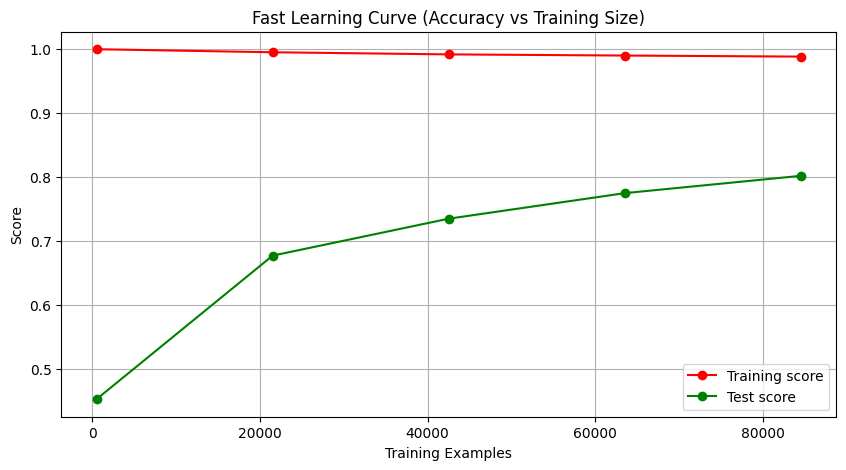

<module 'matplotlib.pyplot' from 'c:\\Users\\AsreRayaneh\\miniconda3\\envs\\rahdari\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [39]:
import numpy as np
learning_curve(model=model)

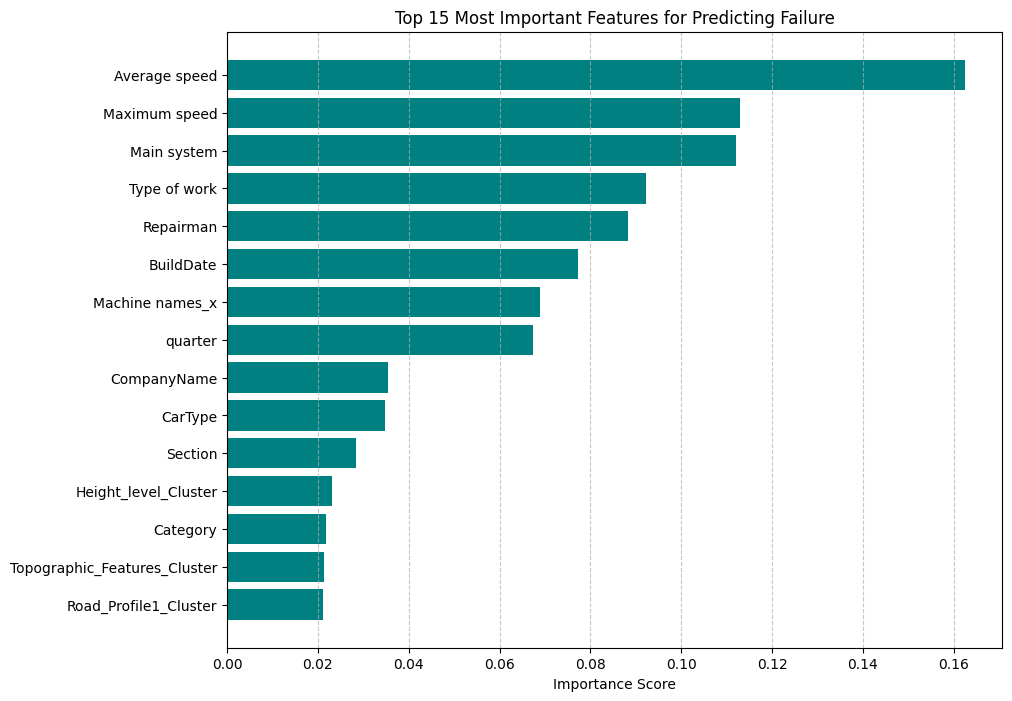

            Feature  Importance
9     Average speed    0.162505
10    Maximum speed    0.112971
13      Main system    0.112103
1      Type of work    0.092208
12        Repairman    0.088240
7         BuildDate    0.077238
0   Machine names_x    0.068789
2           quarter    0.067354
3       CompanyName    0.035507
8           CarType    0.034752


In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pull the importance from the model
importances = model.feature_importances_

# 2. Match them with the column names
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the top 15 features
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'][:15][::-1], feature_importance_df['Importance'][:15][::-1], color='teal')
plt.title('Top 15 Most Important Features for Predicting Failure')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(feature_importance_df.head(10))

In [114]:
df = Merged_Full_Data[Merged_Full_Data['duration'] > 0]

In [115]:
total_rows = len(df)
print(f"Total rows in dataset: {total_rows}")

Total rows in dataset: 47631


In [116]:
df['duration_category'] = pd.qcut(df['duration'], q=5, labels=[0, 1, 2, 3, 4])
# 1. Define Features (X) and Target (y)
# Ensure you use the 'Failure_Class' we created earlier (0, 1, 2)
X = df[features]
y = df['duration_category']

# 2. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Validation Scores
print("--- Validation Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

C:\Users\AsreRayaneh\AppData\Local\Temp\ipykernel_14652\2395450042.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



--- Validation Metrics ---
Accuracy Score: 81.56%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1944
           1       0.80      0.80      0.80      1990
           2       0.78      0.76      0.77      1846
           3       0.79      0.80      0.79      1899
           4       0.86      0.86      0.86      1848

    accuracy                           0.82      9527
   macro avg       0.82      0.82      0.82      9527
weighted avg       0.82      0.82      0.82      9527



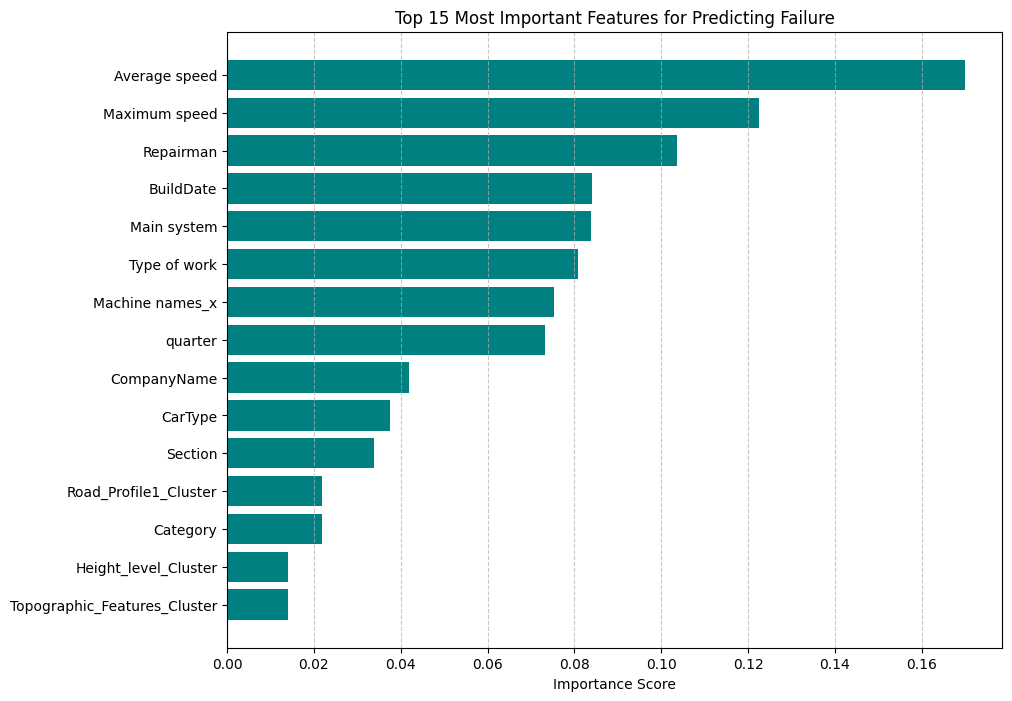

            Feature  Importance
9     Average speed    0.170007
10    Maximum speed    0.122578
12        Repairman    0.103682
7         BuildDate    0.084154
13      Main system    0.083759
1      Type of work    0.080718
0   Machine names_x    0.075380
2           quarter    0.073290
3       CompanyName    0.041836
8           CarType    0.037622


In [117]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pull the importance from the model
importances = model.feature_importances_

# 2. Match them with the column names
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the top 15 features
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'][:15][::-1], feature_importance_df['Importance'][:15][::-1], color='teal')
plt.title('Top 15 Most Important Features for Predicting Failure')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(feature_importance_df.head(10))

In [72]:
cf['MBF_category'] = pd.qcut(cf['Mileage between failuers'], q=5, labels=[0, 1, 2, 3, 4])
# 1. Define Features (X) and Target (y)
# Ensure you use the 'Failure_Class' we created earlier (0, 1, 2)
X = cf[features]
y = cf['MBF_category']

# 2. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Validation Scores
print("--- Validation Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

C:\Users\AsreRayaneh\AppData\Local\Temp\ipykernel_14652\1848748446.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



--- Validation Metrics ---
Accuracy Score: 44.36%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.66      0.64       594
           1       0.42      0.39      0.41       594
           2       0.34      0.34      0.34       594
           3       0.31      0.30      0.30       595
           4       0.50      0.53      0.51       594

    accuracy                           0.44      2971
   macro avg       0.44      0.44      0.44      2971
weighted avg       0.44      0.44      0.44      2971



In [73]:
total_rows = len(cf)
print(f"Total rows in dataset: {total_rows}")

Total rows in dataset: 14855


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pull the importance from the model
importances = model.feature_importances_

# 2. Match them with the column names
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the top 15 features
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'][:15][::-1], feature_importance_df['Importance'][:15][::-1], color='teal')
plt.title('Top 15 Most Important Features for Predicting Failure')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(feature_importance_df.head(10))